# Day 3

## Classical machine learning approaches with Scikit-learn

Notebook prepared by Nuno R. C. Gomes, IEEC/ICE-CSIC | v20260505

###### Cerdanyola del Vallès, Barcelona, 18-22 May 2026

----

Welcome to day 3 of our Machine Learning course! 👋

Today, we dive into **classical ML techniques** using the powerful and beginner-friendly library **Scikit-learn**.
In this notebook, we will explore:
- **Supervised learning**:
  - **Regression**: predict continuous outcomes with models like Linear Regression, Ridge, Lasso, Elastic Net, K-NN, and Decision Trees.
  - **Classification**: predict categorical outcomes using Logistic Regression, Naïve Bayes, k-Nearest Neighbors (k-NN), and Decision Trees.
- **Unsupervised learning**: discover patterns in unlabeled data with K-Means Clustering.
- **Model tuning**: learn how to optimise models using **k-fold cross-validation** and **hyperparameter tuning**.

By the end of this session, you will not only understand how these algorithms work but also how to apply, evaluate, and improve them on real data sets.

Let's jump in and start turning data into insight!

---

## Imports & configuration

In [35]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.datasets import load_breast_cancer, load_diabetes
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import (
  ElasticNet, ElasticNetCV,
  Lasso, LassoCV,
  LinearRegression,
  LogisticRegression,
  Ridge, RidgeCV
)
from sklearn.metrics import (
  accuracy_score, 
  classification_report,
  confusion_matrix,
  f1_score,
  make_scorer,
  mean_absolute_error,
  mean_squared_error,
  precision_score,
  recall_score,
  r2_score,
  RocCurveDisplay, roc_curve, auc
)
from sklearn.model_selection import (
  cross_val_score,
  GridSearchCV,
  KFold,
  train_test_split,
)
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor

In [4]:
RND = 42

---

## Supervised learning

### Regression

We will be using the Diabetes data set in this section.
The goal is to predict the disease progression from clinical features.

In [5]:
# load data
diabetes = load_diabetes()
X_reg = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)
y_reg = diabetes.target

# train/test split (to prevent data leakage)
X_trn_r, X_tst_r, y_trn_r, y_tst_r = train_test_split(
  X_reg, y_reg, test_size=0.2, random_state=RND
)

print(f"Total samples: {len(X_reg)}")
print(f"Training samples: {len(X_trn_r)}")
print(f"Testing samples: {len(X_tst_r)}")

Total samples: 442
Training samples: 353
Testing samples: 89


We initisalise all models in a dictionary for clean looping.

In [17]:
models = {
  "Linear Regression": LinearRegression(),
  "Ridge Regression": Ridge(alpha=1.0),
  "Lasso Regression": Lasso(alpha=1.0, random_state=RND),
  "Elastic Net": ElasticNet(alpha=1.0, l1_ratio=0.5, random_state=RND),
  "K-Nearest Neighbors": KNeighborsRegressor(n_neighbors=5),
  "Regression Tree": DecisionTreeRegressor(max_depth=4, random_state=RND)
}

We now iterate through all the models, train them, and capture the quality metrics.

In [18]:
performance_metrics = []

for model_name, model_instance in models.items():
  # fit the model onto the training data
  model_instance.fit(X_trn_r, y_trn_r)
  
  # generate predictions on the unseen test set
  predictions = model_instance.predict(X_tst_r)
  
  # calculate performance metrics
  mae = mean_absolute_error(y_tst_r, predictions)
  rmse = np.sqrt(mean_squared_error(y_tst_r, predictions))
  r2 = r2_score(y_tst_r, predictions)
  
  # store the results
  performance_metrics.append({
    "Model": model_name,
    "MAE": round(mae, 2),
    "RMSE": round(rmse, 2),
    "R-squared": round(r2, 4)
  })

# compile results into structured Pandas data frame
df_assess = pd.DataFrame(performance_metrics)

# Sort by R-squared in descending order (best performing models at the top)
df_assess = df_assess.sort_values(
  by="R-squared", ascending=False
).reset_index(drop=True)

# display final quality assessment table
print("\n=== Regression quality assessment comparison ===")
df_assess


=== Regression quality assessment comparison ===


,Model,MAE,RMSE,R-squared
0,Linear Regression,42.79,53.85,0.4526
1,K-Nearest Neighbors,42.77,54.95,0.4302
2,Ridge Regression,46.14,55.47,0.4192
3,Lasso Regression,49.73,58.34,0.3576
4,Regression Tree,47.05,59.74,0.3264
5,Elastic Net,63.71,72.88,-0.0025


#### Inspect coefficients for zeroed-out features

To see which noisy features have been completely nullified (set to exactly 0) by Lasso, we can inspect the `.coef_` attribute of the fitted model and pair it with our feature names.

In [19]:
lasso = Lasso(alpha=1, random_state=RND)
lasso.fit(X_trn_r, y_trn_r)

lasso_coefs = pd.DataFrame({
  'Feature': X_reg.columns,
  'Coefficient': lasso.coef_
})

# filter to show features that were completely dropped
dropped_features = lasso_coefs[lasso_coefs['Coefficient'] == 0]
print(dropped_features)

  Feature  Coefficient
0     age          0.0
1     sex         -0.0
4      s1          0.0
5      s2          0.0
6      s3         -0.0
7      s4          0.0
9      s6          0.0


#### Model comparison with grid-search tunning

The code below has been updated to include `GridSearchCV` for hyperparameter tuning across all models (except basic Linear Regression, which has no regularisation parameters to tune).
It also automatically extracts the coefficient counts to show how many features each linear model eliminated.

In [ ]:
# define models and their hyperparameter spaces for tuning
configs = {
  "Linear Regression": {
    "model": LinearRegression(),
    "grid": {} # no hyperparameters to tune
  },
  "Ridge Regression": {
    "model": Ridge(),
    "grid": {"alpha": [0.01, 0.1, 1.0, 10.0, 100.0]}
  },
  "Lasso Regression": {
    "model": Lasso(random_state=RND, max_iter=10000),
    "grid": {"alpha": [0.001, 0.01, 0.1, 1.0, 10.0]}
  },
  "Elastic Net": {
    "model": ElasticNet(random_state=RND, max_iter=10000),
    "grid": {
      "alpha": [0.01, 0.1, 1.0, 10.0],
      "l1_ratio": [0.2, 0.5, 0.8]
    }
  },
  "K-Nearest Neighbors": {
    "model": KNeighborsRegressor(),
    "grid": {
      "n_neighbors": [3, 5, 7, 11, 15],
      "weights": ["uniform", "distance"]
    }
  },
  "Regression Tree": {
    "model": DecisionTreeRegressor(random_state=RND),
    "grid": {
      "max_depth": [3, 5, 7, 10, None],
      "min_samples_split": [2, 5, 10]
    }
  }
}

performance_metrics = []
coefficients_dict = {}

# loop through each model configuration
for name, config in configs.items():
  # setup grid search with 5-fold cross-validation scoring on R-squared
  grid_search = GridSearchCV(
    estimator=config["model"],
    param_grid=config["grid"],
    cv=5,
    scoring="r2", # "neg_root_mean_squared_error"
    n_jobs=-1
  )
  
  # fit grid search on training data
  grid_search.fit(X_trn_r, y_trn_r)
  best_model = grid_search.best_estimator_
  
  # evaluate on unseen testing data
  predictions = best_model.predict(X_tst_r)
  mae = mean_absolute_error(y_tst_r, predictions)
  rmse = np.sqrt(mean_squared_error(y_tst_r, predictions))
  r2 = r2_score(y_tst_r, predictions)
  
  # track features set to zero if model uses coefficients
  zeroed_features = "N/A"
  if hasattr(best_model, "coef_"):
    coefficients_dict[name] = best_model.coef_
    zeroed_features = np.sum(best_model.coef_ == 0)
  
  performance_metrics.append({
    "Model": name,
    "Best Parameters": str(grid_search.best_params_),
    "Features Eliminated": zeroed_features,
    "MAE": round(mae, 2),
    "RMSE": round(rmse, 2),
    "R-squared": round(r2, 4)
  })

# compile results into summary table
df_assess = pd.DataFrame(performance_metrics)
df_assess = df_assess.sort_values(by="R-squared", ascending=False).reset_index(drop=True)

print("\n=== Tuned regression quality assessment comparison ===")
print(df_assess.to_string())

print("\n=== Coefficient inspection ===")
for model_name, coefs in coefficients_dict.items():
  if model_name in ["Lasso Regression", "Elastic Net", "Ridge Regression"]:
    print(f"\n{model_name} coefficients:")
    for feat, coef in zip(X_reg.columns, coefs):
      print(f"  {feat}: {coef:.4f}")


=== Tuned regression quality assessment comparison ===
                 Model                             Best Parameters Features Eliminated    MAE   RMSE  R-squared
0     Lasso Regression                              {'alpha': 0.1}                   3  42.85  52.90     0.4719
1     Ridge Regression                              {'alpha': 0.1}                   0  43.00  53.45     0.4609
2    Linear Regression                                          {}                   0  42.79  53.85     0.4526
3          Elastic Net            {'alpha': 0.01, 'l1_ratio': 0.8}                   0  45.24  54.61     0.4371
4  K-Nearest Neighbors  {'n_neighbors': 15, 'weights': 'distance'}                 N/A  44.51  54.86     0.4320
5      Regression Tree    {'max_depth': 3, 'min_samples_split': 2}                 N/A  48.10  59.60     0.3294

=== Coefficient inspection ===

Ridge Regression coefficients:
  age: 42.8557
  sex: -205.4943
  bmi: 505.0890
  bp: 317.0932
  s1: -108.5003
  s2: -86.2367
  

### Classification

For this section, we will be using the Breast Cancer data set to classify tumours as _malignant_ or _benign_.

In [23]:
# load data set
cancer = load_breast_cancer()
X_clf = pd.DataFrame(cancer.data, columns=cancer.feature_names)
y_clf = cancer.target

# train/test split
X_trn_c, X_tst_c, y_trn_c, y_tst_c = train_test_split(
  X_clf, y_clf, test_size=0.2, stratify=y_clf, random_state=RND
)

In [ ]:
# define models and their respective hyperparameter grids
# we use Pipeline for models that require feature standardisation
configs = {
  # "Logistic Regression": {
  #   "pipeline": Pipeline([
  #     ("scaler", StandardScaler()),
  #     ("model", LogisticRegression(solver="liblinear", random_state=RND))
  #   ]),
  #   "grid": {
  #     "model__C": [0.01, 0.1, 1.0, 10.0, 100.0],
  #     "model__penalty": ["l1", "l2"]
  #   }
  # },
  "Logistic Regression": {
    "pipeline": Pipeline([
      ("scaler", StandardScaler()),
      # use 'saga' & increase max_iter to ensure convergence
      (
        "model",
        LogisticRegression(solver="saga", random_state=RND, max_iter=10000)
      )
    ]),
    "grid": {
      "model__C": [0.01, 0.1, 1.0, 10.0, 100.0],
      "model__l1_ratio": [0.0, 1.0] # 0.0 is L2 (Ridge), 1.0 is L1 (Lasso)
    }
  },
  "Naïve Bayes": {
    "pipeline": Pipeline([
      ("scaler", StandardScaler()), # NB doesn't strictly need it, but keeps setup uniform
      ("model", GaussianNB())
    ]),
    "grid": {
      "model__var_smoothing": np.logspace(0, -9, num=10)
    }
  },
  "K-Nearest Neighbors": {
    "pipeline": Pipeline([
      ("scaler", StandardScaler()),
      ("model", KNeighborsClassifier())
    ]),
    "grid": {
      "model__n_neighbors": [3, 5, 7, 11, 15],
      "model__weights": ["uniform", "distance"]
    }
  },
  "Classification Tree": {
    "pipeline": Pipeline([
      ("model", DecisionTreeClassifier(random_state=RND)) # trees do not require scaling
    ]),
    "grid": {
      "model__max_depth": [3, 5, 7, 10, None],
      "model__criterion": ["gini", "entropy"],
      "model__min_samples_split": [2, 5, 10]
    }
  }
}

In [42]:
# iterate through pipelines, execute grid-search, analyse performance
classification_metrics = []

for name, config in configs.items():
  # optimise the model based on accuracy using 5-fold cross-validation
  grid_search = GridSearchCV(
    estimator=config["pipeline"],
    param_grid=config["grid"],
    cv=5,
    scoring="accuracy",
    n_jobs=-1
  )
  
  grid_search.fit(X_trn_c, y_trn_c)
  best_model = grid_search.best_estimator_
  
  # predict on unseen validation test set
  predictions = best_model.predict(X_tst_c)
  
  # calculate multiple classification metrics for thorough assessment
  acc = accuracy_score(y_tst_c, predictions)
  prec = precision_score(y_tst_c, predictions, zero_division=0)
  rec = recall_score(y_tst_c, predictions)
  f1 = f1_score(y_tst_c, predictions)
  
  classification_metrics.append({
    "Model": name,
    "Best Parameters": str(grid_search.best_params_),
    "Accuracy": round(acc, 4),
    "Precision": round(prec, 4),
    "Recall (Sensitivity)": round(rec, 4),
    "F1-Score": round(f1, 4)
  })

# compile & display final evaluation matrix
df_assess = pd.DataFrame(classification_metrics)
df_assess = df_assess.sort_values(
  by="Accuracy", ascending=False
).reset_index(drop=True)

print("\n=== Tuned classification quality assessment ===")
df_assess


=== Tuned classification quality assessment ===


,Model,Best Parameters,Accuracy,Precision,Recall (Sensitivity),F1-Score
0,Logistic Regression,"{'model__C': 0.1, 'model__l1_ratio': 0.0}",0.9737,0.9726,0.9861,0.9793
1,K-Nearest Neighbors,"{'model__n_neighbors': 7, 'model__weights': 'u...",0.9737,0.9600,1.0000,0.9796
2,Naïve Bayes,{'model__var_smoothing': np.float64(0.1)},0.9474,0.9459,0.9722,0.9589
3,Classification Tree,"{'model__criterion': 'gini', 'model__max_depth...",0.9211,0.9565,0.9167,0.9362


#### ROC curve for the logistic regression case

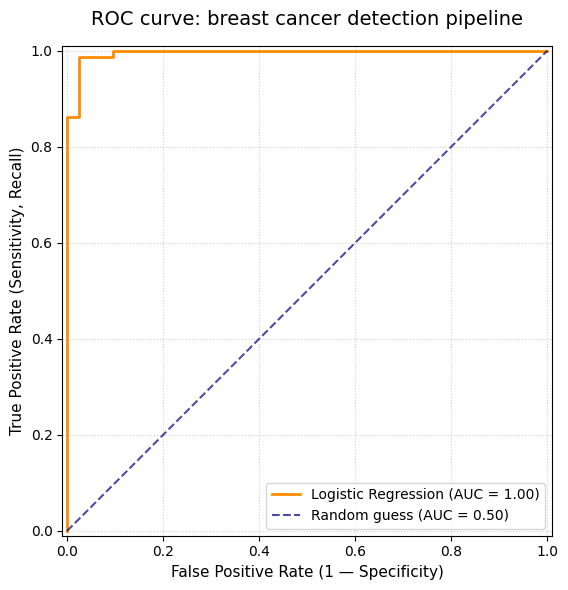

In [43]:
# re-initialise winning configuration from grid search
# use parameters that yielded the top score in benchmark
best_lr_pipeline = Pipeline([
  ("scaler", StandardScaler()),
  ("model", LogisticRegression(
    C=0.1, 
    solver="saga", 
    l1_ratio=0.0, 
    random_state=RND, 
    max_iter=10000
  ))
])

# fit pipeline on training data
best_lr_pipeline.fit(X_trn_c, y_trn_c)

# create plot
fig, ax = plt.subplots(figsize=(7, 6))

styling_options = {
  "color": "darkorange",
  "linewidth": 2
}

RocCurveDisplay.from_estimator(
  estimator=best_lr_pipeline,
  X=X_tst_c,
  y=y_tst_c,
  ax=ax,
  name="Logistic Regression",
  curve_kwargs=styling_options
)

# add baseline diagonal line representing completely random classifier
ax.plot(
  [0, 1], [0, 1],
  linestyle="--", color="navy", alpha=0.7, label="Random guess (AUC = 0.50)"
)

# customise and polish presentation layout
ax.set_title("ROC curve: breast cancer detection pipeline", fontsize=14, pad=15)
ax.set_xlabel("False Positive Rate (1 — Specificity)", fontsize=11)
ax.set_ylabel("True Positive Rate (Sensitivity, Recall)", fontsize=11)
ax.grid(True, linestyle=":", alpha=0.6)
ax.legend(loc="lower right", frameon=True)

# clean rendering adjustment
plt.tight_layout();

In [ ]:
# 1. Update to the modern API standard using l1_ratio instead of penalty
# solver='saga' natively handles the l1_ratio framework (0.0 means pure L2/Ridge)
best_lr_pipeline = Pipeline([
  ("scaler", StandardScaler()),
  ("model", LogisticRegression(
    C=0.1, 
    solver="saga", 
    l1_ratio=0.0, 
    random_state=RND, 
    max_iter=10000
  ))
])

# 2. Fit the pipeline on the training data
best_lr_pipeline.fit(X_trn, y_trn)

# 3. Create the plot using the updated curve_kwargs standard
fig, ax = plt.subplots(figsize=(7, 6))

# Moving design properties into a dictionary to appease the new API
styling_options = {
  "color": "darkorange",
  "linewidth": 2
}

RocCurveDisplay.from_estimator(
  estimator=best_lr_pipeline,
  X=X_tst,
  y=y_tst,
  ax=ax,
  name="Logistic Regression",
  curve_kwargs=styling_options
)

# 4. Add a baseline diagonal line representing a completely random classifier
ax.plot([0, 1], [0, 1], linestyle="--", color="navy", alpha=0.7, label="Random Guess (AUC = 0.50)")

# 5. Customise and polish the presentation layout
ax.set_title("ROC Curve: Breast Cancer Detection Pipeline", fontsize=14, pad=15)
ax.set_xlabel("False Positive Rate (1 - Specificity)", fontsize=11)
ax.set_ylabel("True Positive Rate (Sensitivity / Recall)", fontsize=11)
ax.grid(True, linestyle=":", alpha=0.6)
ax.legend(loc="lower right", frameon=True)

# Clean rendering adjustment
plt.tight_layout()

In [36]:
# random forest classifier
rf = RandomForestClassifier(n_estimators=100, random_state=RND)
rf.fit(X_trn_c, y_trn_c)
y_prd_c = rf.predict(X_tst_c)

print("\n--- Classification report (Random Forest) ---")
print(classification_report(y_tst_c, y_prd_c))


--- Classification report (Random Forest) ---
              precision    recall  f1-score   support

           0       0.98      0.93      0.95        43
           1       0.96      0.99      0.97        71

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



### Visualisation of a ROC curve

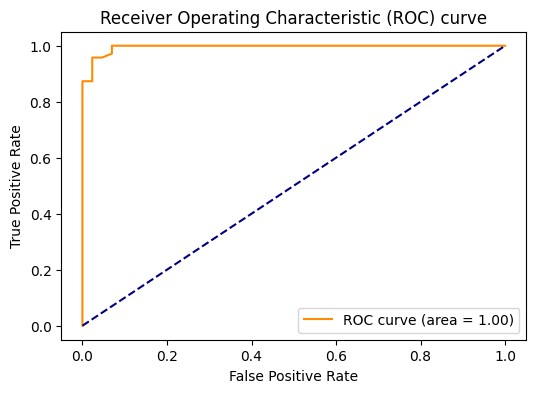

In [15]:
y_probs = rf.predict_proba(X_tst_c)[:, 1]
fpr, tpr, thresholds = roc_curve(y_tst_c, y_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 4))
plt.plot(
  fpr, tpr, color='darkorange', label=f'ROC curve (area = {roc_auc:.2f})'
)
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) curve')
plt.legend(loc="lower right");

---

## Unsupervised learning

### K-means clustering

We will cluster based on the first two features of the Breast Cancer data set.

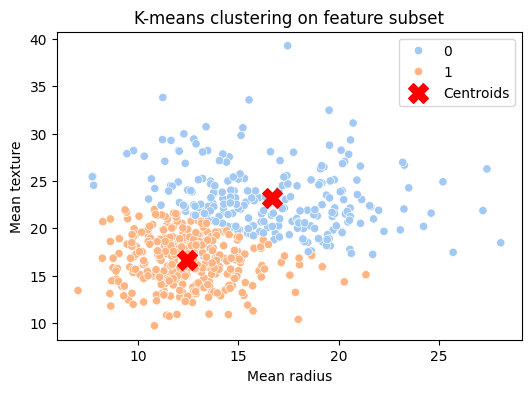

In [35]:
X_cluster = X_clf.iloc[:, :2]
kmeans = KMeans(n_clusters=2, random_state=RND, n_init=10)
kmeans.fit(X_cluster)

plt.figure(figsize=(6, 4))
sns.scatterplot(
  x=X_cluster.iloc[:, 0], y=X_cluster.iloc[:, 1],
  hue=kmeans.labels_, palette='pastel'
)
plt.scatter(
  kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
  s=200, c='red', marker='X', label='Centroids'
)
plt.title("K-means clustering on feature subset")
plt.xlabel("Mean radius")
plt.ylabel("Mean texture")
plt.legend();

## Hyperparameter tunning and cross-validation

In [24]:
param_grid = {
  'n_estimators': [50, 100],
  'max_depth': [None, 10, 20],
  'min_samples_split': [2, 5]
}
grid_search = GridSearchCV(
  RandomForestClassifier(random_state=RND), param_grid, cv=5
)
grid_search.fit(X_trn_c, y_trn_c)

print(f"\nBest parameters: {grid_search.best_params_}")
print(f"Best CV score: {grid_search.best_score_:.4f}")


Best parameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}
Best CV score: 0.9582


## Rigorous scaling

We will:
- Initialise a scaler;
- Compute the mean/std **from the training set only**;
- Standardise the training data using these values;
- Standardise the testing data using the **same training mean/std**;
- Result: **scaled features** that are compatible for ML, while avoiding leakage.

In [46]:
# scale only using training mean/std to avoid 'peeking' at test set
scaler = StandardScaler()
X_trn_scaled = scaler.fit_transform(X_trn_c)
X_tst_scaled = scaler.transform(X_tst_c)

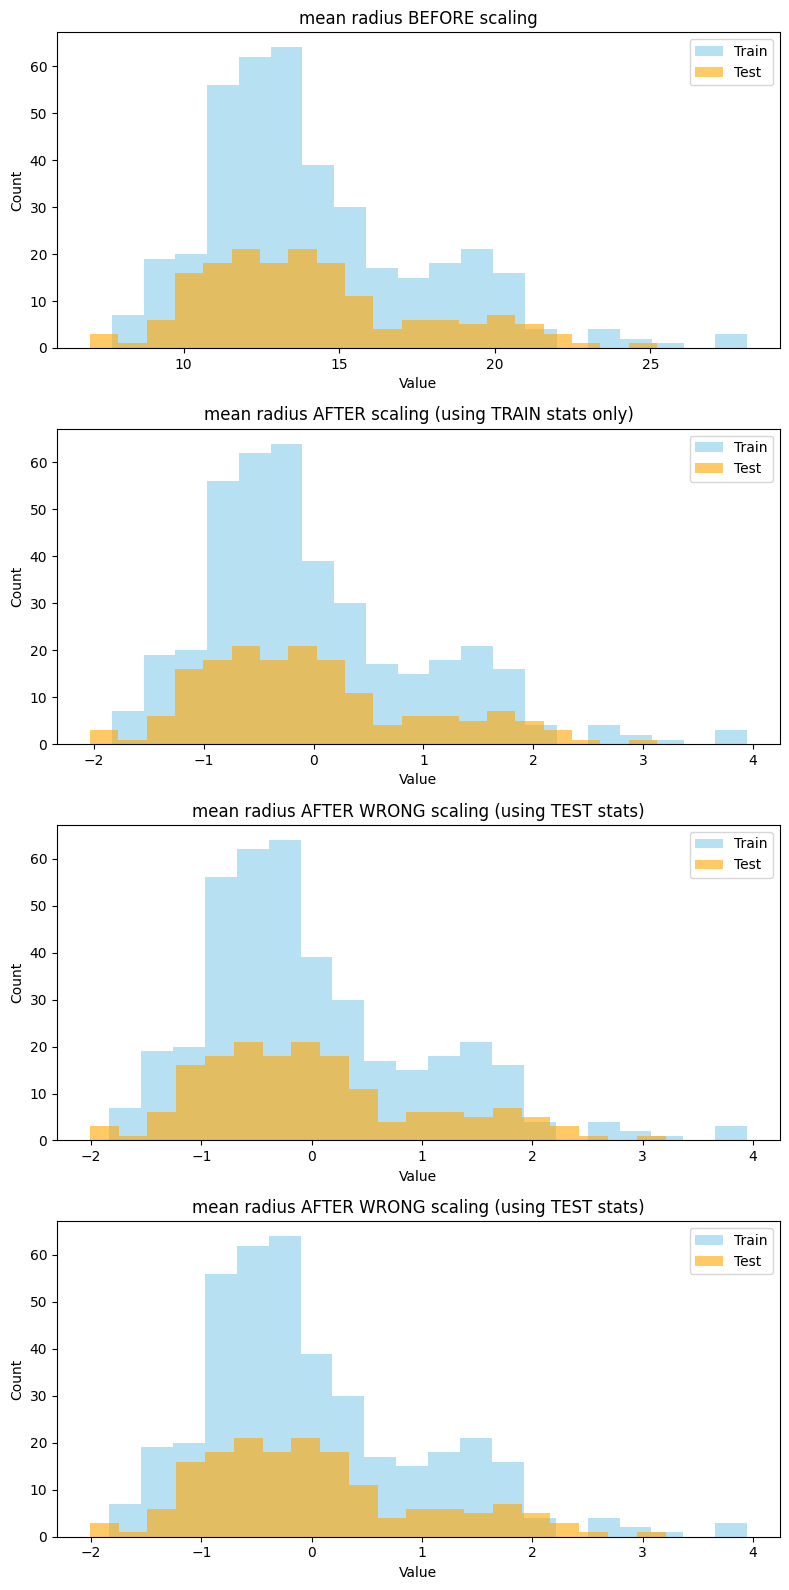

In [59]:
# data
X = cancer.data
y = cancer.target
feature_names = cancer.feature_names

# train/test split
X_trn, X_tst, y_trn, y_tst = train_test_split(
  X, y, test_size=0.3, random_state=RND
)

# pick feature to visualise
feature_idx = 0 # mean radius, for example
feature_name = feature_names[feature_idx]

# visualise before scaling
plt.figure(figsize=(8, 16))
plt.subplot(4, 1, 1)
plt.hist(
  X_trn[:, feature_idx], bins=20, alpha=0.6, label='Train', color='skyblue'
)
plt.hist(
  X_tst[:, feature_idx], bins=20, alpha=0.6, label='Test', color='orange'
)
plt.title(f"{feature_name} BEFORE scaling")
plt.xlabel("Value")
plt.ylabel("Count")
plt.legend()

# scale data properly
scaler = StandardScaler()
X_trn_scaled = scaler.fit_transform(X_trn)
X_tst_scaled = scaler.transform(X_tst)
# visualise after scaling
plt.subplot(4, 1, 2)
plt.hist(
  X_trn_scaled[:, feature_idx],
  bins=20, alpha=0.6, label="Train", color="skyblue"
)
plt.hist(
  X_tst_scaled[:, feature_idx],
  bins=20, alpha=0.6, label="Test", color="orange"
)
plt.title(f"{feature_name} AFTER scaling (using TRAIN stats only)")
plt.xlabel("Value")
plt.ylabel("Count")
plt.legend()

# scale data wrongly
scaler_wrong_trn = StandardScaler()
X_trn_wrong = scaler_wrong_trn.fit_transform(X_trn)
scaler_wrong_tst = StandardScaler()
X_tst_wrong = scaler_wrong_tst.fit_transform(X_tst)
# visualise after wrong scaling
plt.subplot(4, 1, 3)
plt.hist(
  X_trn_wrong[:, feature_idx],
  bins=20, alpha=0.6, label="Train", color="skyblue"
)
plt.hist(
  X_tst_wrong[:, feature_idx],
  bins=20, alpha=0.6, label="Test", color="orange"
)
plt.title(f"{feature_name} AFTER WRONG scaling (using TEST stats)")
plt.xlabel("Value")
plt.ylabel("Count")
plt.legend()

# scale data wrongly
X_tst_wrong_2 = scaler.fit_transform(X_tst)
# visualise after wrong scaling
plt.subplot(4, 1, 4)
plt.hist(
  X_trn_scaled[:, feature_idx],
  bins=20, alpha=0.6, label="Train", color="skyblue"
)
plt.hist(
  X_tst_wrong_2[:, feature_idx],
  bins=20, alpha=0.6, label="Test", color="orange"
)
plt.title(f"{feature_name} AFTER WRONG scaling (using TEST stats)")
plt.xlabel("Value")
plt.ylabel("Count")
plt.legend()
plt.tight_layout();

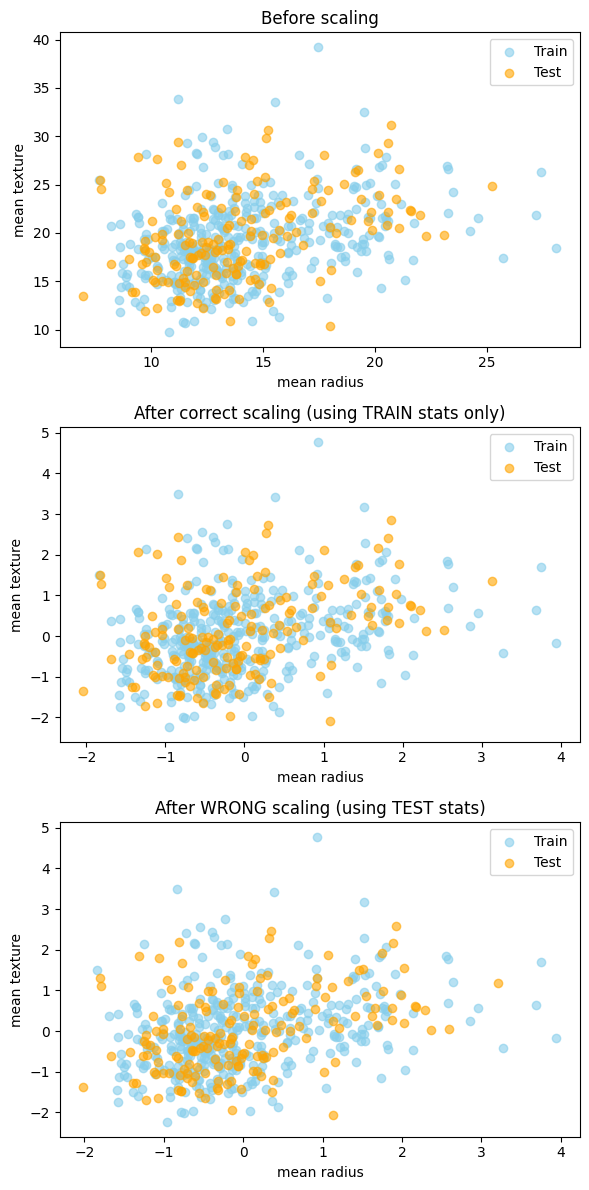

In [65]:
# pick two features for scatter plot
f1_idx, f2_idx = 0, 1 # mean radius & mean texture
f1_name, f2_name = feature_names[f1_idx], feature_names[f2_idx]

# scale data properly
scaler = StandardScaler()
X_trn_scaled = scaler.fit_transform(X_trn)
X_tst_scaled = scaler.transform(X_tst)

# scale data wrongly (peeked at test set)
scaler_wrong_trn = StandardScaler()
X_trn_wrong = scaler_wrong_trn.fit_transform(X_trn)

scaler_wrong_tst = StandardScaler()
X_tst_wrong = scaler_wrong_tst.fit_transform(X_tst)

# scatter plots
fig, axs = plt.subplots(3, 1, figsize=(6, 12))

# before scaling
axs[0].scatter(
  X_trn[:, f1_idx], X_trn[:, f2_idx], c='skyblue', label='Train', alpha=0.6
)
axs[0].scatter(
  X_tst[:, f1_idx], X_tst[:, f2_idx], c='orange', label='Test', alpha=0.6
)
axs[0].set_title("Before scaling")
axs[0].set_xlabel(f1_name)
axs[0].set_ylabel(f2_name)
axs[0].legend()

# after correct scaling
axs[1].scatter(
  X_trn_scaled[:, f1_idx], X_trn_scaled[:,
  f2_idx], c='skyblue', label='Train', alpha=0.6
)
axs[1].scatter(
  X_tst_scaled[:, f1_idx], X_tst_scaled[:,
  f2_idx], c='orange', label='Test', alpha=0.6
)
axs[1].set_title("After correct scaling (using TRAIN stats only)")
axs[1].set_xlabel(f1_name)
axs[1].set_ylabel(f2_name)
axs[1].legend()

# after wrong scaling
axs[2].scatter(X_trn_wrong[:, f1_idx], X_trn_wrong[:, f2_idx], c='skyblue', label='Train', alpha=0.6)
axs[2].scatter(X_tst_wrong[:, f1_idx], X_tst_wrong[:, f2_idx], c='orange', label='Test', alpha=0.6)
axs[2].set_title("After WRONG scaling (using TEST stats)")
axs[2].set_xlabel(f1_name)
axs[2].set_ylabel(f2_name)
axs[2].legend()

plt.tight_layout();

## K-fold cross-validation

In this section, we are going to assess the stability of a linear regression model using five-fold cross-validation.

In [68]:
model = LinearRegression()
kf = KFold(n_splits=5, shuffle=True, random_state=RND)

# cross_val_score performs K-fold loop
scores = cross_val_score(model, X_trn_scaled, y_trn, cv=kf, scoring='r2')

print(f"\nK-fold R2 scores: {scores}")
print(f"Mean R2: {np.mean(scores):.4f}")
print(f"Standard deviation: {np.std(scores):.4f} (lower is more stable)")


K-fold R2 scores: [0.72559276 0.68067192 0.71412457 0.73029598 0.75693079]
Mean R2: 0.7215
Standard deviation: 0.0248 (lower is more stable)


## Regularisation as model selection

We will compare Lasso (L1) and Ridge (L2).

In [72]:
ridge = Ridge(alpha=1.0)
lasso = Lasso(alpha=0.1)

ridge.fit(X_trn_scaled, y_trn)
lasso.fit(X_trn_scaled, y_trn)

# scientific insight: Lasso's feature selection
lasso_coefs = pd.Series(lasso.coef_, index=cancer.feature_names)
print("\nLasso coefficients (variables forced to zero are removed):")
print(lasso_coefs[lasso_coefs != 0])

# Ridge's feature selection
ridge_coefs = pd.Series(ridge.coef_, index=cancer.feature_names)
print("\nRidge coefficients (variables forced to zero are removed):")
print(ridge_coefs[ridge_coefs != 0])


Lasso coefficients (variables forced to zero are removed):
mean concave points    -0.043137
worst radius           -0.110872
worst texture          -0.009914
worst concave points   -0.154851
dtype: float64

Ridge coefficients (variables forced to zero are removed):
mean radius               -0.104870
mean texture               0.028803
mean perimeter            -0.062916
mean area                  0.119871
mean smoothness           -0.024921
mean compactness           0.218232
mean concavity            -0.040192
mean concave points       -0.214925
mean symmetry              0.015327
mean fractal dimension    -0.008807
radius error              -0.210259
texture error              0.040482
perimeter error            0.015597
area error                 0.127698
smoothness error          -0.071723
compactness error          0.036753
concavity error            0.118956
concave points error      -0.101478
symmetry error             0.015796
fractal dimension error    0.001553
worst radius 

## Final evaluation

Only now we touch the testing data set.

In [74]:
test_score_lasso = lasso.score(X_tst_scaled, y_tst)
test_score_ridge = ridge.score(X_tst_scaled, y_tst)
print("\nFinal test R2 score (unseen data)")
print("-"*33)
print(f"Lasso: {test_score_lasso:.4f}")
print(f"Ridge: {test_score_ridge:.4f}")


Final test R2 score (unseen data)
---------------------------------
Lasso: 0.6770
Ridge: 0.7201


**Hands-on tasks**:

1. Change the `alpha` parameter in Lasso and see how many features get removed.
1. Use cross-validation to find the optimal value for `alpha` in both Lasso and Ridge.

In [86]:
print("\nLasso coefficients (variables forced to zero are removed)")
print("-"*57)
alphas = [0.01, 0.05, 0.1, 0.2, 0.5]
for alpha in alphas:
  print(f"alpha = {alpha}:")
  lasso = Lasso(alpha=alpha)
  lasso.fit(X_trn_scaled, y_trn)
  lasso_coefs = pd.Series(lasso.coef_, index=cancer.feature_names)
  non_zero = lasso_coefs[lasso_coefs != 0]
  for var, coef in non_zero.items():
    print(f"\t{var:<25} {coef:.4f}")


Lasso coefficients (variables forced to zero are removed)
---------------------------------------------------------
alpha = 0.01:
	mean texture              -0.0045
	mean concave points       -0.0913
	mean fractal dimension    0.0210
	radius error              -0.0184
	smoothness error          -0.0132
	compactness error         0.0050
	concavity error           0.0115
	worst radius              -0.1401
	worst texture             -0.0637
	worst smoothness          -0.0186
	worst concavity           -0.0487
	worst concave points      -0.0830
	worst symmetry            -0.0449
alpha = 0.05:
	mean concave points       -0.0721
	worst radius              -0.1308
	worst texture             -0.0456
	worst concavity           -0.0027
	worst concave points      -0.1405
	worst symmetry            -0.0129
alpha = 0.1:
	mean concave points       -0.0431
	worst radius              -0.1109
	worst texture             -0.0099
	worst concave points      -0.1549
alpha = 0.2:
	mean concave points       

#### Cross-validation

##### Using `LassoCV()` and `RidgeCV()`

In [94]:
# Lasso with 5-fold CV
alphas = [0.001, 0.01, 0.1, 0.5, 1, 10, 100]
lasso_cv = LassoCV(alphas=alphas, cv=5, random_state=RND)
lasso_cv.fit(X_trn_scaled, y_trn)
print(f"Best alpha for Lasso: {lasso_cv.alpha_}")
print(f"CV score for Lasso: {lasso_cv.score(X_tst_scaled, y_tst)}\n")

# Ridge with 5-fold CV
ridge_cv = RidgeCV(alphas=alphas, cv=5)
ridge_cv.fit(X_trn_scaled, y_trn)
print(f"Best alpha for Ridge: {ridge_cv.alpha_}")
print(f"CV score for Ridge: {ridge_cv.score(X_tst_scaled, y_tst)}")

Best alpha for Lasso: 0.001
CV score for Lasso: 0.7412443789109229

Best alpha for Ridge: 10.0
CV score for Ridge: 0.7459521402307276


##### Using `GridSearchCV()`

In [93]:
alphas = [0.001, 0.01, 0.1, 0.5, 1, 10, 100]
param_grid = {'alpha': alphas}

# Lasso grid search
lasso_grid = GridSearchCV(Lasso(), param_grid, cv=5)
lasso_grid.fit(X_trn_scaled, y_trn)
best_lasso = lasso_grid.best_estimator_
test_score_lasso = best_lasso.score(X_tst_scaled, y_tst)
print(f"Best alpha for Lasso: {lasso_grid.best_params_['alpha']}")
print(f"Best CV score for Lasso: {lasso_grid.best_score_}")
print(f"Test R2 for Lasso: {test_score_lasso}\n")

# Ridge grid search
ridge_grid = GridSearchCV(Ridge(), param_grid, cv=5)
ridge_grid.fit(X_trn_scaled, y_trn)
best_ridge = ridge_grid.best_estimator_
test_score_ridge = best_ridge.score(X_tst_scaled, y_tst)
print(f"Best alpha for Ridge: {ridge_grid.best_params_['alpha']}")
print(f"Best CV score for Ridge: {ridge_grid.best_score_}")
print(f"Test R2 for Ridge: {test_score_ridge}")

Best alpha for Lasso: 0.001
Best CV score for Lasso: 0.7144916854886697
Test R2 for Lasso: 0.7412443789109229

Best alpha for Ridge: 10
Best CV score for Ridge: 0.7029325811343821
Test R2 for Ridge: 0.7459521402307276


##### Complete example using RMSE

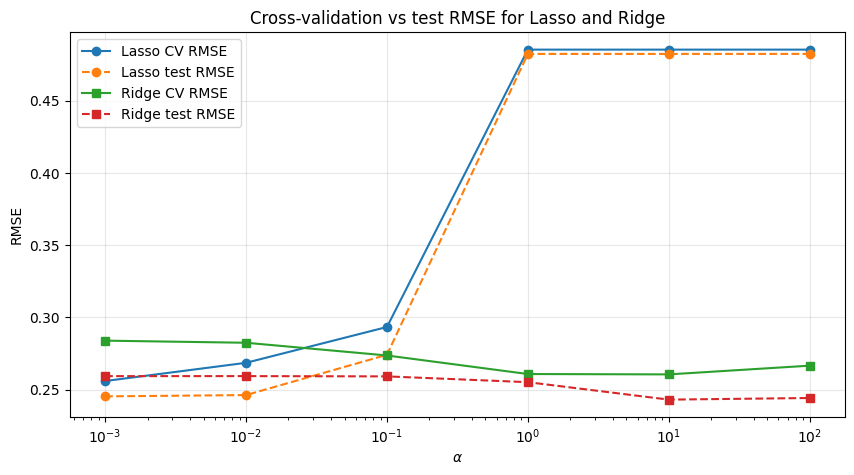

In [96]:
# load data set
cancer = load_breast_cancer()
X = cancer.data
y = cancer.target

# train/test split
RND = 42
X_trn, X_tst, y_trn, y_tst = train_test_split(
  X, y, test_size=0.3, random_state=RND
)

# scale features
scaler = StandardScaler()
X_trn_scaled = scaler.fit_transform(X_trn)
X_tst_scaled = scaler.transform(X_tst)

# candidate alphas
alphas = [0.001, 0.01, 0.1, 1, 10, 100]

# containers to store CV and test scores
rmse_cv_lasso, rmse_test_lasso = [], []
rmse_cv_ridge, rmse_test_ridge = [], []

# evaluate each alpha
for alpha in alphas:
  # Lasso
  lasso = Lasso(alpha=alpha, random_state=RND)
  # CV RMSE (neg_mean_squared_error is used by scikit-learn)
  scores = cross_val_score(
    lasso, X_trn_scaled, y_trn, cv=5, scoring='neg_mean_squared_error'
  )
  rmse_cv_lasso.append(np.mean(np.sqrt(-scores)))
  lasso.fit(X_trn_scaled, y_trn)
  rmse_test_lasso.append(
    np.sqrt(mean_squared_error(y_tst, lasso.predict(X_tst_scaled)))
  )
  
  # Ridge
  ridge = Ridge(alpha=alpha)
  scores = cross_val_score(
    ridge, X_trn_scaled, y_trn, cv=5, scoring='neg_mean_squared_error'
  )
  rmse_cv_ridge.append(np.mean(np.sqrt(-scores)))
  ridge.fit(X_trn_scaled, y_trn)
  rmse_test_ridge.append(
    np.sqrt(mean_squared_error(y_tst, ridge.predict(X_tst_scaled)))
  )

# plot CV vs test RMSE
plt.figure(figsize=(10, 5))
plt.plot(alphas, rmse_cv_lasso, marker='o', label='Lasso CV RMSE')
plt.plot(
  alphas, rmse_test_lasso, marker='o', linestyle='--', label='Lasso test RMSE'
)
plt.plot(alphas, rmse_cv_ridge, marker='s', label='Ridge CV RMSE')
plt.plot(
  alphas, rmse_test_ridge, marker='s', linestyle='--', label='Ridge test RMSE'
)
plt.xscale("log")
plt.xlabel(r"$\alpha$")
plt.ylabel("RMSE")
plt.title("Cross-validation vs test RMSE for Lasso and Ridge")
plt.legend()
plt.grid(True, alpha=0.3);